In [ ]:
# Cell 1: Imports and configuration

import os
import random

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# BraTS HDF5 slice dataset (same structure as TumorTrace notebook)[file:1]
DATA_DIR = "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data"
IMAGE_KEY = "image"  # (240,240,4)
MASK_KEY = "mask"    # (240,240,3) one-hot (NCR, Edema, ET)[file:1]

NUM_CLASSES = 4  # 0=BG, 1=NCR/NET, 2=Edema, 3=ET
BATCH_SIZE = 32
VAL_FRACTION = 0.1
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

CKPT_PATH = "/kaggle/working/unet_multiclass.pth"

In [7]:
# Cell 2: BraTS slice dataset — 4-class mask (0..3)

class BraTSMultiSliceDataset(Dataset):
    """
    Returns:
      img:  (4, H, W) float32 normalized
      mask: (H, W) int64 labels in {0,1,2,3}

    Class mapping:
      0 = Background
      1 = NCR/NET
      2 = Edema
      3 = ET
    """
    def __init__(self, root_dir, image_key, mask_key, augment=False):
        self.root_dir = root_dir
        self.image_key = image_key
        self.mask_key = mask_key
        self.augment = augment

        self.files = sorted(
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.endswith(".h5")
        )
        assert len(self.files) > 0, "No .h5 files found — check DATA_DIR"

    def __len__(self):
        return len(self.files)

    def _normalize(self, img):
        # Per-slice, per-channel z-score normalization
        mean = img.mean(axis=(0, 1), keepdims=True)
        std = img.std(axis=(0, 1), keepdims=True) + 1e-8
        return (img - mean) / std

    def _augment(self, img, mask):
        # Simple flips
        if random.random() < 0.5:
            img = np.flip(img, axis=1).copy()
            mask = np.flip(mask, axis=1).copy()

        if random.random() < 0.5:
            img = np.flip(img, axis=0).copy()
            mask = np.flip(mask, axis=0).copy()

        return img, mask

    def __getitem__(self, idx):
        with h5py.File(self.files[idx], "r") as f:
            img = f[self.image_key][()].astype(np.float32)   # (H,W,4)
            mask = f[self.mask_key][()]                      # (H,W) or (H,W,3)

        img = self._normalize(img)

        # Convert one-hot 3-channel tumour mask -> proper 4-class label map
        # 0 = background, 1 = NCR/NET, 2 = Edema, 3 = ET
        if mask.ndim == 3 and mask.shape[-1] == 3:
            label_map = np.zeros(mask.shape[:2], dtype=np.int64)
            label_map[mask[..., 0] > 0.5] = 1   # NCR/NET
            label_map[mask[..., 1] > 0.5] = 2   # Edema
            label_map[mask[..., 2] > 0.5] = 3   # ET
            mask = label_map
        else:
            mask = mask.astype(np.int64)

        if self.augment:
            img, mask = self._augment(img, mask)

        img_t = torch.from_numpy(np.transpose(img, (2, 0, 1))).float()  # (4,H,W)
        mask_t = torch.from_numpy(mask).long()                           # (H,W)

        return img_t, mask_t


# Create dataset
full_dataset = BraTSMultiSliceDataset(
    root_dir=DATA_DIR,
    image_key=IMAGE_KEY,
    mask_key=MASK_KEY,
    augment=True
)

# Train / val split
n_val = int(len(full_dataset) * VAL_FRACTION)
n_train = len(full_dataset) - n_val

train_ds, val_ds = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train slices: {len(train_ds)} | Val slices: {len(val_ds)}")

Train slices: 51476 | Val slices: 5719


Image batch: torch.Size([32, 4, 240, 240])
Mask batch : torch.Size([32, 240, 240])
Unique labels in batch: [0, 1, 2, 3]
Unique labels in selected slice: [0 1 2 3]


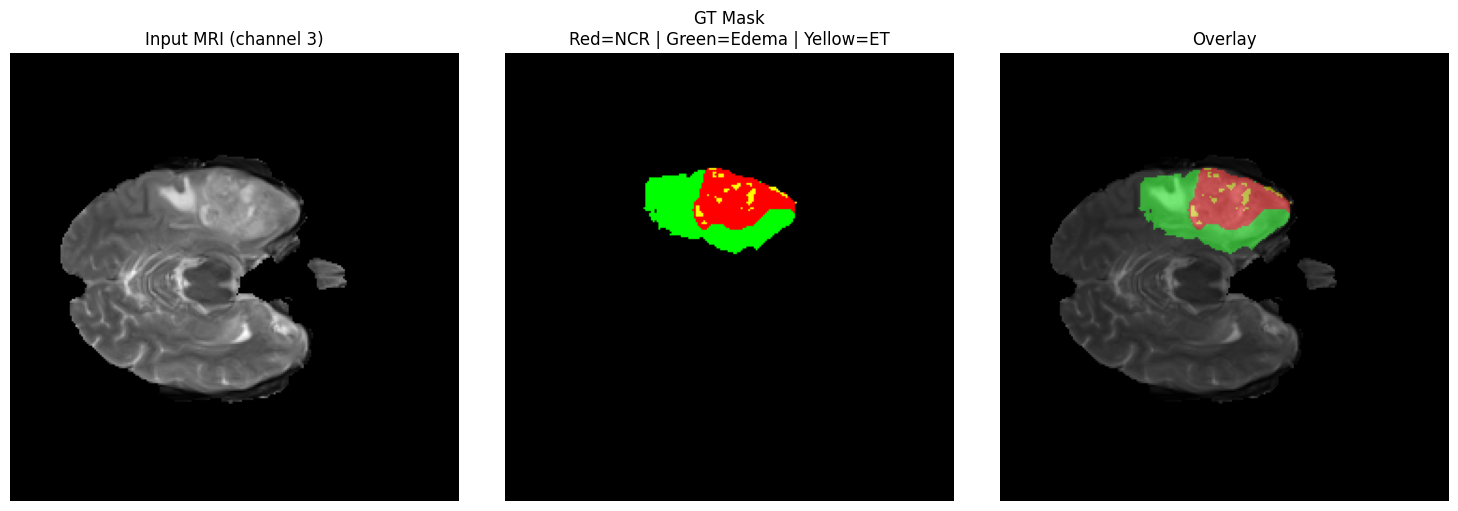

In [9]:
# Cell 3: Sanity check a batch and visualize masks properly

imgs, masks = next(iter(train_loader))

print("Image batch:", imgs.shape)     # expected: (B, 4, H, W)
print("Mask batch :", masks.shape)    # expected: (B, H, W)
print("Unique labels in batch:", torch.unique(masks).tolist())

# Pick one sample
idx = random.randint(0, imgs.shape[0] - 1)
ch = 3   # usually FLAIR-like channel

img_np = imgs[idx, ch].cpu().numpy()
mask_np = masks[idx].cpu().numpy()

print("Unique labels in selected slice:", np.unique(mask_np))

# Create a custom display mask so colours are easier to see
# 0 = black, 1 = red, 2 = green, 3 = yellow
color_mask = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)
color_mask[mask_np == 1] = [255, 0, 0]      # NCR/NET -> red
color_mask[mask_np == 2] = [0, 255, 0]      # Edema   -> green
color_mask[mask_np == 3] = [255, 255, 0]    # ET      -> yellow

plt.figure(figsize=(15, 5))

# MRI input
plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title(f"Input MRI (channel {ch})")
plt.axis("off")

# GT mask only
plt.subplot(1, 3, 2)
plt.imshow(color_mask)
plt.title("GT Mask\nRed=NCR | Green=Edema | Yellow=ET")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(img_np, cmap="gray")
plt.imshow(color_mask, alpha=0.45)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Cell 4: 2D U-Net for 4-class brain tumour segmentation

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.mp = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch, dropout_p)
        )

    def forward(self, x):
        return self.mp(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True, dropout_p=0.0):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, dropout_p)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, 2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch, dropout_p)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Pad if necessary
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2,
                       diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNetMulti(nn.Module):
    def __init__(self, in_ch=4, n_classes=4, base=32, dropout_p=0.2, bilinear=True):
        super().__init__()
        factor = 2 if bilinear else 1
        self.inc = DoubleConv(in_ch, base, dropout_p)
        self.d1 = Down(base, base*2, dropout_p)
        self.d2 = Down(base*2, base*4, dropout_p)
        self.d3 = Down(base*4, base*8, dropout_p)
        self.d4 = Down(base*8, base*16//factor, dropout_p)
        self.u1 = Up(base*16, base*8//factor, bilinear, dropout_p)
        self.u2 = Up(base*8, base*4//factor, bilinear, dropout_p)
        self.u3 = Up(base*4, base*2//factor, bilinear, dropout_p)
        self.u4 = Up(base*2, base, bilinear, dropout_p)
        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)
        x5 = self.d4(x4)
        x = self.u1(x5, x4)
        x = self.u2(x, x3)
        x = self.u3(x, x2)
        x = self.u4(x, x1)
        return self.outc(x)


unet = UNetMulti(in_ch=4, n_classes=NUM_CLASSES, base=32, dropout_p=0.2).to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters()) / 1e6
print(f"UNet parameters: {n_params:.2f}M")

UNet parameters: 3.35M


In [11]:
# Cell 5: Loss (CrossEntropy + Dice) and Dice metric

def one_hot(labels, n_classes, device):
    # labels: (B,H,W) -> (B,C,H,W)
    return F.one_hot(labels.to(torch.int64), n_classes).permute(0,3,1,2).float().to(device)


def dice_loss_multiclass(logits, targets, eps=1e-6):
    """
    logits: (B,C,H,W), targets: (B,H,W)
    """
    probs = F.softmax(logits, dim=1)
    tgt_oh = one_hot(targets, logits.shape[1], logits.device)
    dims = (0,2,3)
    inter = torch.sum(probs * tgt_oh, dims)
    card  = torch.sum(probs + tgt_oh, dims)
    dice = (2.0*inter + eps) / (card + eps)
    # average dice over classes, subtract from 1
    return 1.0 - dice.mean()


def combined_loss_multiclass(logits, targets, alpha=0.5):
    ce = F.cross_entropy(logits, targets)
    dl = dice_loss_multiclass(logits, targets)
    return alpha*ce + (1-alpha)*dl, ce.detach(), dl.detach()


@torch.no_grad()
def dice_score_multiclass(logits, targets, eps=1e-6):
    """
    Mean Dice over classes for evaluation.
    """
    n_cls = logits.shape[1]
    preds = torch.argmax(logits, dim=1)
    p_oh = one_hot(preds, n_cls, logits.device)
    t_oh = one_hot(targets, n_cls, logits.device)
    dims = (0,2,3)
    inter = torch.sum(p_oh * t_oh, dims)
    card  = torch.sum(p_oh + t_oh, dims)
    dice = (2.0*inter + eps) / (card + eps)
    return dice.mean().item()

In [13]:
# Cell 6: Optimizer and LR scheduler (safe version)

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LR_FACTOR = 0.5
LR_PATIENCE = 2

optimizer = torch.optim.AdamW(
    params=unet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PATIENCE
)

print("Optimizer:", optimizer)
print("Scheduler:", scheduler)
print("Current LR:", optimizer.param_groups[0]["lr"])

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7dfad4a8f920>
Current LR: 0.001


In [14]:
# Cell 7: Loss function and Dice metric

criterion = torch.nn.CrossEntropyLoss()

def multiclass_dice_score(logits, targets, num_classes=4, eps=1e-6):
    """
    logits:  (B, C, H, W)
    targets: (B, H, W)
    returns: mean Dice across tumour classes only (1,2,3), ignoring background
    """
    preds = torch.argmax(logits, dim=1)  # (B, H, W)

    dice_scores = []

    for cls in range(1, num_classes):  # ignore background class 0
        pred_cls = (preds == cls).float()
        true_cls = (targets == cls).float()

        intersection = (pred_cls * true_cls).sum(dim=(1, 2))
        union = pred_cls.sum(dim=(1, 2)) + true_cls.sum(dim=(1, 2))

        dice = (2.0 * intersection + eps) / (union + eps)
        dice_scores.append(dice.mean())

    return torch.mean(torch.stack(dice_scores)).item()

In [17]:
# Cell 8: Train and validation loops with batch-wise printing

def train_one_epoch(model, loader, optimizer, criterion, device, epoch_num=1, total_epochs=1):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    total_batches = len(loader)

    for batch_idx, (imgs, masks) in enumerate(loader, start=1):
        imgs = imgs.to(device, non_blocking=True)      # (B,4,H,W)
        masks = masks.to(device, non_blocking=True)    # (B,H,W)

        optimizer.zero_grad()

        outputs = model(imgs)                          # (B,4,H,W)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        batch_dice = multiclass_dice_score(outputs.detach(), masks)

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / batch_idx
        avg_dice = running_dice / batch_idx

        print(
            f"[Epoch {epoch_num}/{total_epochs}] "
            f"Train Batch {batch_idx}/{total_batches} | "
            f"Loss: {loss.item():.4f} | Dice: {batch_dice:.4f} | "
            f"Avg Loss: {avg_loss:.4f} | Avg Dice: {avg_dice:.4f}"
        )

    epoch_loss = running_loss / total_batches
    epoch_dice = running_dice / total_batches

    return epoch_loss, epoch_dice


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, epoch_num=1, total_epochs=1):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    total_batches = len(loader)

    for batch_idx, (imgs, masks) in enumerate(loader, start=1):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        batch_dice = multiclass_dice_score(outputs, masks)

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / batch_idx
        avg_dice = running_dice / batch_idx

        print(
            f"[Epoch {epoch_num}/{total_epochs}] "
            f"Val Batch {batch_idx}/{total_batches} | "
            f"Loss: {loss.item():.4f} | Dice: {batch_dice:.4f} | "
            f"Avg Loss: {avg_loss:.4f} | Avg Dice: {avg_dice:.4f}"
        )

    epoch_loss = running_loss / total_batches
    epoch_dice = running_dice / total_batches

    return epoch_loss, epoch_dice

In [18]:
# Cell 9: Main training loop with epoch-wise and batch-wise output

NUM_EPOCHS = 20
best_val_dice = 0.0

history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    print("\n" + "=" * 80)
    print(f"Starting Epoch {epoch}/{NUM_EPOCHS}")
    print("=" * 80)

    train_loss, train_dice = train_one_epoch(
        model=unet,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        epoch_num=epoch,
        total_epochs=NUM_EPOCHS
    )

    print("-" * 80)
    print(f"Epoch {epoch} Training Done | Avg Train Loss: {train_loss:.4f} | Avg Train Dice: {train_dice:.4f}")
    print("-" * 80)

    val_loss, val_dice = validate_one_epoch(
        model=unet,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch_num=epoch,
        total_epochs=NUM_EPOCHS
    )

    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print("-" * 80)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS} Summary | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}"
    )
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(unet.state_dict(), "best_unet_model.pth")
        print(f" New best model saved! Best Val Dice: {best_val_dice:.4f}")

    print("=" * 80)

print("\nTraining completed.")
print("Best Validation Dice:", best_val_dice)


Starting Epoch 1/20
[Epoch 1/20] Train Batch 1/1609 | Loss: 0.0151 | Dice: 0.8036 | Avg Loss: 0.0151 | Avg Dice: 0.8036
[Epoch 1/20] Train Batch 2/1609 | Loss: 0.0101 | Dice: 0.8241 | Avg Loss: 0.0126 | Avg Dice: 0.8138
[Epoch 1/20] Train Batch 3/1609 | Loss: 0.0118 | Dice: 0.7632 | Avg Loss: 0.0123 | Avg Dice: 0.7970
[Epoch 1/20] Train Batch 4/1609 | Loss: 0.0372 | Dice: 0.6818 | Avg Loss: 0.0186 | Avg Dice: 0.7682
[Epoch 1/20] Train Batch 5/1609 | Loss: 0.0135 | Dice: 0.8715 | Avg Loss: 0.0175 | Avg Dice: 0.7888
[Epoch 1/20] Train Batch 6/1609 | Loss: 0.0156 | Dice: 0.7669 | Avg Loss: 0.0172 | Avg Dice: 0.7852
[Epoch 1/20] Train Batch 7/1609 | Loss: 0.0320 | Dice: 0.7287 | Avg Loss: 0.0193 | Avg Dice: 0.7771
[Epoch 1/20] Train Batch 8/1609 | Loss: 0.0211 | Dice: 0.7687 | Avg Loss: 0.0195 | Avg Dice: 0.7761
[Epoch 1/20] Train Batch 9/1609 | Loss: 0.0215 | Dice: 0.7725 | Avg Loss: 0.0198 | Avg Dice: 0.7757
[Epoch 1/20] Train Batch 10/1609 | Loss: 0.0141 | Dice: 0.7588 | Avg Loss: 0.01

In [24]:
# Fix cell: define heuristic_survival_from_masks before predict_single_patient()

import torch

# Example survival class labels
SURV_LABELS = {
    0: "Short Survival",
    1: "Mid Survival",
    2: "Long Survival"
}

def heuristic_survival_from_masks(pred_masks):
    """
    pred_masks: tensor of shape (B, H, W) with classes:
        0 = background
        1 = NCR/NET
        2 = Edema
        3 = ET

    Returns:
        surv_class: tensor of shape (B,) with values 0,1,2
        et_frac: tensor of shape (B,) = fraction of ET pixels
    """

    batch_size = pred_masks.shape[0]
    surv_classes = []
    et_fracs = []

    for i in range(batch_size):
        mask = pred_masks[i]

        total_pixels = mask.numel()
        et_pixels = (mask == 3).sum().float()
        edema_pixels = (mask == 2).sum().float()
        ncr_pixels = (mask == 1).sum().float()

        et_frac = et_pixels / total_pixels
        tumor_frac = (et_pixels + edema_pixels + ncr_pixels) / total_pixels

        # Simple heuristic:
        # larger ET / tumour burden -> poorer survival
        if et_frac > 0.03 or tumor_frac > 0.12:
            surv_class = 0   # Short Survival
        elif et_frac > 0.01 or tumor_frac > 0.05:
            surv_class = 1   # Mid Survival
        else:
            surv_class = 2   # Long Survival

        surv_classes.append(surv_class)
        et_fracs.append(et_frac)

    surv_classes = torch.tensor(surv_classes, dtype=torch.long)
    et_fracs = torch.stack(et_fracs)

    return surv_classes, et_fracs

In [25]:
# Cell 11: Single patient end-to-end function

LABEL_COLORS = np.array([
    [0,   0,   0,   0],     # 0 BG transparent
    [255, 0,   0, 180],     # 1 NCR/NET red
    [0, 255,   0, 180],     # 2 Edema green
    [255, 255, 0, 200],     # 3 ET yellow
], dtype=np.uint8)


def make_overlay(flair_slice, pred_mask):
    """
    flair_slice: (H,W) float
    pred_mask: (H,W) int in {0..3}
    Returns: (H,W,4) uint8 RGBA overlay
    """
    f = flair_slice
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    rgb = np.stack([f, f, f], axis=-1) * 255.0
    rgb = rgb.astype(np.uint8)

    # Overlay each tumour class
    rgba = np.dstack([rgb, np.full_like(rgb[...,0], 255, dtype=np.uint8)])
    for cls_id in range(1, 4):
        mask = (pred_mask == cls_id)
        if not mask.any():
            continue
        col = LABEL_COLORS[cls_id]
        # alpha blend: new = 0.65*old + 0.35*color
        rgba[mask, :3] = (
            0.65 * rgba[mask, :3].astype(np.float32) +
            0.35 * col[:3].astype(np.float32)
        ).astype(np.uint8)
        rgba[mask, 3] = col[3]
    return rgba


def predict_single_patient(h5_path, patient_age, model, image_key=IMAGE_KEY, mask_key=MASK_KEY):
    """
    h5_path: path to one .h5 slice (4 modalities + mask)
    patient_age: float, in years
    model: trained UNetMulti
    """
    # Load & normalize (same as dataset)
    with h5py.File(h5_path, "r") as f:
        img = f[image_key][()].astype(np.float32)   # (H,W,4)
        gt_mask = f[mask_key][()]                  # GT if you want to visualise

    if gt_mask.ndim == 3 and gt_mask.shape[-1] > 1:
        gt_mask = np.argmax(gt_mask, axis=-1)

    H, W, _ = img.shape
    mean = img.mean(axis=(0,1), keepdims=True)
    std  = img.std(axis=(0,1), keepdims=True) + 1e-8
    img_n = (img - mean) / std

    img_t = torch.from_numpy(np.transpose(img_n, (2,0,1))).unsqueeze(0).to(DEVICE)

    # Segmentation
    pred_masks, conf_maps, prob_maps = segment_batch(model, img_t)
    pred = pred_masks[0].numpy()
    conf = conf_maps[0].numpy()

    # Radiomic + survival (heuristic)
    surv_class, et_frac = heuristic_survival_from_masks(pred_masks)
    surv_idx = int(surv_class[0].item())
    surv_label = SURV_LABELS[surv_idx]
    stats = compute_slice_stats(pred)

    # Overall and per-class percentages
    total_px = H * W
    bg_pct   = stats["counts"][0] / total_px * 100.0
    ncr_pct  = stats["counts"][1] / total_px * 100.0
    ed_pct   = stats["counts"][2] / total_px * 100.0
    et_pct   = stats["counts"][3] / total_px * 100.0
    tumor_pct = stats["tumor_frac"] * 100.0

    main_cls = stats["main_cls"]
    main_type = CLASS_NAMES[main_cls]

    # Summary print
    print("="*60)
    print("TumourTrace-style Patient Summary")
    print(f"File: {os.path.basename(h5_path)}")
    print(f"Patient age: {patient_age:.1f} years")
    print("-"*60)
    print(f"TUMOUR TYPE (dominant sub-region): {main_type}")
    print(f"Whole tumour: {tumor_pct:.2f}% of slice")
    print(f"  NCR/NET   : {ncr_pct:.2f}%")
    print(f"  Edema     : {ed_pct:.2f}%")
    print(f"  Enhancing : {et_pct:.2f}%")
    print(f"Model confidence inside tumour: {conf[pred>0].mean():.3f}" if (pred>0).any() else "No tumour predicted")
    print("-"*60)
    print(f"Heuristic survival category: {surv_label}")
    print(f"  (ET fraction: {et_frac[0].item():.4f})")
    print("="*60)

    # Visuals
    ch = min(3, img_n.shape[-1] - 1)  # FLAIR-like channel
    flair = img_n[:,:,ch]
    overlay = make_overlay(flair, pred)

    fig = plt.figure(figsize=(16,4))
    fig.suptitle(f"Age {patient_age:.1f} yrs — {main_type} — {surv_label}", fontsize=14)

    ax1 = fig.add_subplot(1,4,1)
    ax1.imshow(flair, cmap="gray")
    ax1.set_title("Input (FLAIR)")
    ax1.axis("off")

    ax2 = fig.add_subplot(1,4,2)
    ax2.imshow(pred, cmap="jet", vmin=0, vmax=3)
    ax2.set_title("Predicted Mask")
    ax2.axis("off")

    ax3 = fig.add_subplot(1,4,3)
    ax3.imshow(overlay)
    patches = [
        mpatches.Patch(color=np.array(LABEL_COLORS[i,:3])/255.0, label=CLASS_NAMES[i])
        for i in range(1,4)
    ]
    ax3.legend(handles=patches, loc="lower right", fontsize=8)
    ax3.set_title("Tumour Overlay")
    ax3.axis("off")

    ax4 = fig.add_subplot(1,4,4)
    bars = ax4.barh(
        [CLASS_NAMES[1], CLASS_NAMES[2], CLASS_NAMES[3]],
        [ncr_pct, ed_pct, et_pct],
        color=[
            np.array(LABEL_COLORS[1,:3])/255.0,
            np.array(LABEL_COLORS[2,:3])/255.0,
            np.array(LABEL_COLORS[3,:3])/255.0,
        ]
    )
    ax4.set_xlim(0, max(1.0, tumor_pct) + 1.0)
    ax4.set_xlabel("% of slice")
    ax4.set_title("Per-class tumour %")
    for b, v in zip(bars, [ncr_pct, ed_pct, et_pct]):
        ax4.text(v + 0.2, b.get_y() + b.get_height()/2, f"{v:.2f}%", va="center", fontsize=8)
    ax4.invert_yaxis()

    plt.tight_layout()
    plt.show()

TumourTrace-style Patient Summary
File: volume_146_slice_58.h5
Patient age: 99.0 years
------------------------------------------------------------
TUMOUR TYPE (dominant sub-region): Edema
Whole tumour: 4.05% of slice
  NCR/NET   : 0.89%
  Edema     : 1.98%
  Enhancing : 1.18%
Model confidence inside tumour: 0.881
------------------------------------------------------------
Heuristic survival category: Mid Survival
  (ET fraction: 0.0118)


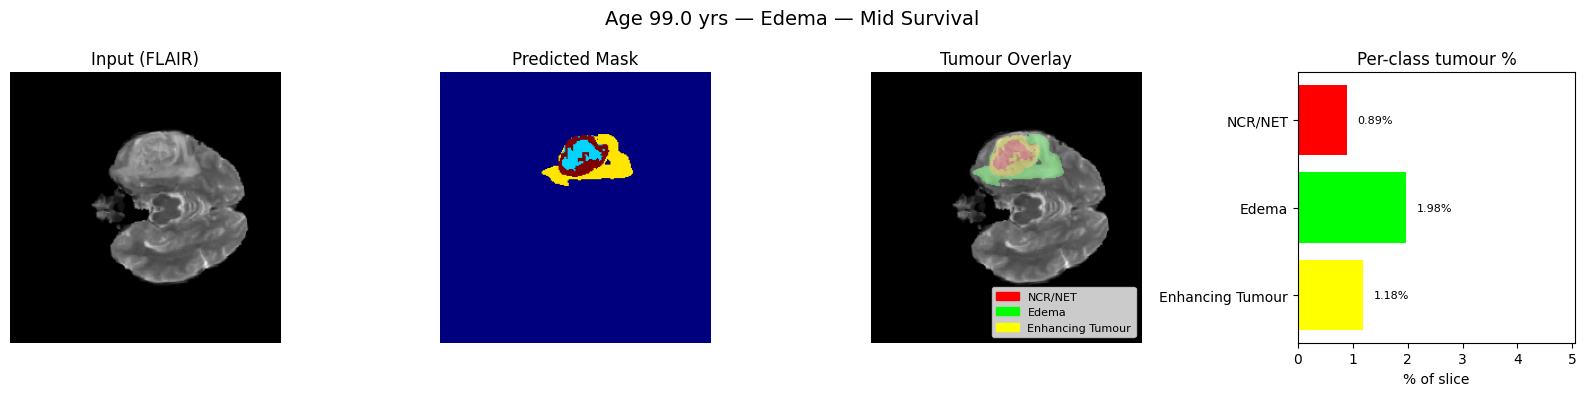

In [31]:
# Cell 12: Demo — run on one .h5 slice + age

# Load best checkpoint if not already loaded
best_unet = UNetMulti(in_ch=4, n_classes=NUM_CLASSES, base=32, dropout_p=0.2).to(DEVICE)
best_unet.load_state_dict(torch.load("/kaggle/working/best_unet_model.pth", map_location=DEVICE))
best_unet.eval()

# Pick any slice from dataset
sample_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".h5")]
sample_path = os.path.join(DATA_DIR, random.choice(sample_files))

# Example age (replace with real patient age)
age_example = 99.0

predict_single_patient(sample_path, age_example, best_unet)